### Задача

1. Смоделируйте данные о расходах 1000 клиентов за месяц по трём категориям:

* Продукты: среднее 20 000 руб., σ = 5000.

* Развлечения: среднее 10 000 руб., σ = 4000.

* Онлайн-покупки: среднее 15 000 руб., σ = 7000.

2. Используя NumPy:

* создайте матрицу 1000×3, где строки — клиенты, а столбцы — категории расходов;

* найдите общие расходы каждого клиента (сумма по строкам);

* посчитайте корреляцию между категориями расходов (np.corrcoef).

3. Дополнительно:

* выделите топ-5% клиентов по общим расходам,

* посчитайте, какой процент общих расходов банка они формируют.

4. Визуализация:

* Постройте boxplot для трёх категорий,

* Постройте scatter plot «Продукты vs Онлайн-покупки» (каждая точка — клиент).

Матрица корреляции между категориями расходов:
[[ 1.         -0.04207606  0.02221055]
 [-0.04207606  1.         -0.01068285]
 [ 0.02221055 -0.01068285  1.        ]]

Топ-5% клиентов (50 человек):
Общие расходы топ-5%: 3254865 руб.
Процент от общих расходов: 7.16%


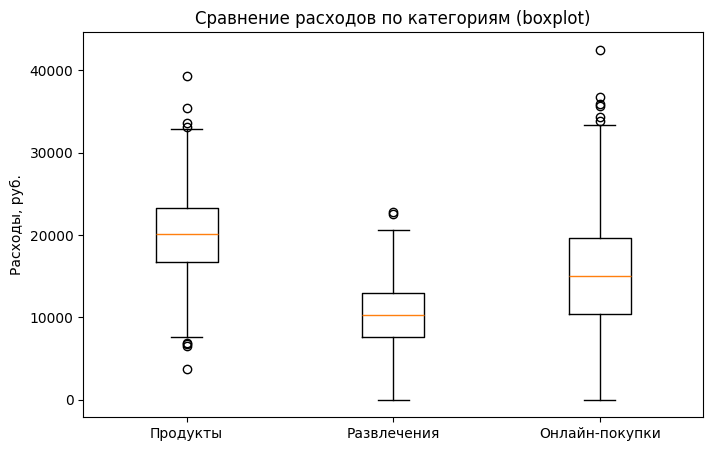

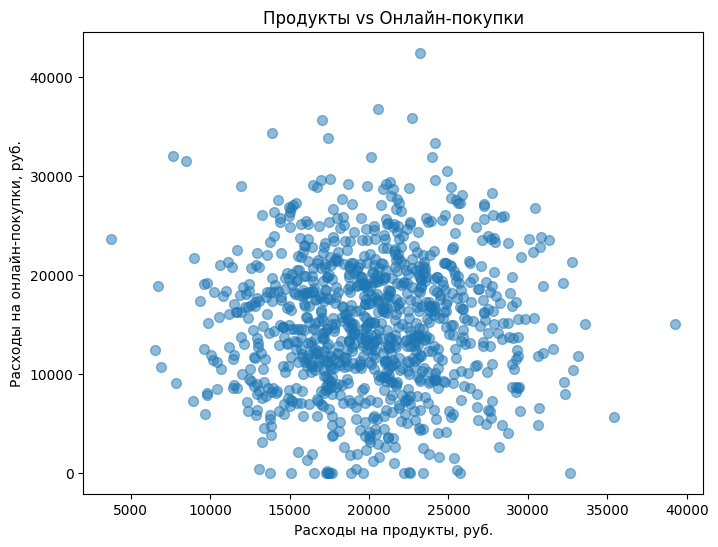

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Фиксируем зерно для воспроизводимости результатов
np.random.seed(42)

# ---------- СИМУЛЯЦИЯ ----------
# Генерируем расходы для 1000 клиентов по трём категориям
products = np.clip(np.random.normal(20_000, 5_000, 1000), 0, None)  # Продукты
entertainment = np.clip(np.random.normal(10_000, 4_000, 1000), 0, None)  # Развлечения
online = np.clip(np.random.normal(15_000, 7_000, 1000), 0, None)  # Онлайн-покупки

# Создаём матрицу 1000×3
expenses = np.column_stack((products, entertainment, online))

# ---------- АНАЛИЗ ----------
# Общие расходы каждого клиента (сумма по строкам)
total_expenses = np.sum(expenses, axis=1)

# Корреляция между категориями расходов
corr_matrix = np.corrcoef(expenses, rowvar=False)
print("Матрица корреляции между категориями расходов:")
print(corr_matrix)

# Топ-5% клиентов по общим расходам
top_5_percent_idx = np.argsort(total_expenses)[-50:]  # 5% от 1000 = 50 клиентов
top_5_percent_expenses = total_expenses[top_5_percent_idx]
top_5_percent_total = np.sum(top_5_percent_expenses)
all_expenses_total = np.sum(total_expenses)
percent_of_total = (top_5_percent_total / all_expenses_total) * 100
print(f"\nТоп-5% клиентов (50 человек):")
print(f"Общие расходы топ-5%: {top_5_percent_total:.0f} руб.")
print(f"Процент от общих расходов: {percent_of_total:.2f}%")

# ---------- ВИЗУАЛИЗАЦИЯ №1: BOXPLOT ----------
plt.figure(figsize=(8, 5))
plt.boxplot([products, entertainment, online], tick_labels=["Продукты", "Развлечения", "Онлайн-покупки"])
plt.title("Сравнение расходов по категориям (boxplot)")
plt.ylabel("Расходы, руб.")
plt.show()

# ---------- ВИЗУАЛИЗАЦИЯ №2: SCATTER PLOT ----------
plt.figure(figsize=(8, 6))
plt.scatter(products, online, alpha=0.5, s=50)
plt.title("Продукты vs Онлайн-покупки")
plt.xlabel("Расходы на продукты, руб.")
plt.ylabel("Расходы на онлайн-покупки, руб.")
plt.show()